# 14. Business Insights — 20 Final Questions


> **Dataset note:** This project uses a synthetic OTT viewer-behaviour dataset for educational analysis.  
> **Hotstar is used only as the business case/scenario; the data is not claimed to be proprietary Hotstar data.**

**Allowed tools:** Python, NumPy, Pandas, Matplotlib, Seaborn.  
**Not used:** Scikit-learn, Plotly, Power BI, Tableau, machine learning, or statistical libraries beyond NumPy/Pandas.

## Process Performed
I answered all 20 final business questions with reproducible Pandas/NumPy calculations and converted the results into decision-oriented outputs for the Hotstar scenario.

In [1]:
# PROCESS: Load the CSV into a Pandas DataFrame and verify that the file loaded correctly.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

DATA_PATH = "ott_viewer_dropoff_retention_us_v1.0.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (33171, 23)


,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,dialogue_density,visual_intensity,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk,dataset_version
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,1,48,4,5,high,5,39,3,0,0,9,high,0,1,0.649,high,v1.0
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,2,55,5,4,low,8,55,3,3,1,5,medium,0,0,0.473,medium,v1.0
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,3,51,4,8,high,7,46,4,2,0,9,high,0,0,0.583,medium,v1.0
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,4,50,4,7,medium,3,50,4,1,0,7,high,0,0,0.520,medium,v1.0
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,5,52,4,3,low,4,35,3,0,1,7,high,0,1,0.638,high,v1.0


## Executive Summary

The EDA indicates that viewer completion, opening strength, pacing, cognitive load, and drop-off probability are the most useful signals for the Hotstar business scenario.

### Key Findings With Numbers

| Finding | Result |
|---|---:|
| Dataset size | 33,171 episode-level records |
| Missing values | 0 |
| Exact duplicate rows | 0 |
| Average watch percentage | 56.81% |
| Average episode duration | 37.66 minutes |
| Highest-engagement genre | Comedy — 77.38 avg. engagement |
| Highest drop-off genre | Drama — 24.19% drop-off rate |
| High retention-risk share | 14.48% |
| Hook strength vs watch % | r ≈ 0.552 |
| Pacing vs engagement | r ≈ 0.566 |
| Cognitive load vs drop-off probability | r ≈ 0.793 |
| Watch % vs drop-off probability | r ≈ -0.957 |

These are descriptive findings from a synthetic dataset and should be interpreted as analytical signals, not real Hotstar customer behavior.

In [2]:
# KERNEL-SAFE SETUP
# Keep plotting memory controlled while preserving the analysis.
import gc

MAX_PLOT_ROWS = 5000

def safe_sample(data, n=MAX_PLOT_ROWS, random_state=42):
    """Use the full data when small; otherwise use a reproducible sample for plotting."""
    return data if len(data) <= n else data.sample(n=n, random_state=random_state)

def finish_plot():
    """Render and release the current Matplotlib figure."""
    plt.tight_layout()
    plt.show()
    plt.close()
    gc.collect()

In [3]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
# Engagement score based on the formula provided in the project brief.
# Watch percentage is already on a 0-100 scale, while the 1-10 content scores
# are multiplied by 5 before combining them.
df["engagement_score"] = (
    df["avg_watch_percentage"]
    + df["hook_strength"] * 5
    + df["pacing_score"] * 5
    + df["visual_intensity"] * 5
) / 2

df["engagement_score"].describe()

count    33171.000000
mean        70.734135
std         12.023213
min         30.000000
25%         62.500000
50%         71.000000
75%         79.500000
max        117.500000
Name: engagement_score, dtype: float64

## 1. Which genre has the highest average viewer engagement?

In [4]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
q1 = df.groupby("genre")["engagement_score"].mean().sort_values(ascending=False)
display(q1)
print("Answer:", q1.index[0], "| Average engagement:", round(q1.iloc[0], 2))

genre
Comedy                77.382784
News                  74.554348
Documentary           72.593333
Crime                 71.687365
Family                71.514423
Sci-Fi & Fantasy      71.234321
Soap                  71.220060
Animation             71.084563
Kids                  71.068038
Talk                  71.042671
Action & Adventure    70.982678
Reality               70.784270
Western               70.577465
War & Politics        69.539216
Mystery               68.688841
Drama                 66.275073
Name: engagement_score, dtype: float64

Answer: Comedy | Average engagement: 77.38


## 2. Which genre has the highest drop-off rate?

In [5]:
# PROCESS: Group episode-level records by genre and compare the requested performance metric.
q2 = (df.groupby("genre")["drop_off"].mean() * 100).sort_values(ascending=False)
display(q2.rename("drop_off_rate_pct"))
print("Answer:", q2.index[0], "| Drop-off rate:", round(q2.iloc[0], 2), "%")

genre
Drama                 24.194074
Mystery               18.884120
Western               18.309859
Documentary           17.333333
Crime                 15.874730
War & Politics        15.686275
Reality               13.558052
Animation             13.482250
Soap                  13.173653
Talk                  13.162970
Sci-Fi & Fantasy      13.066202
Action & Adventure    13.049947
Family                12.980769
Kids                  11.867089
News                   4.347826
Comedy                 2.869253
Name: drop_off_rate_pct, dtype: float64

Answer: Drama | Drop-off rate: 24.19 %


## 3. Which episodes have the highest watch percentage?

In [6]:
# PROCESS: Rank records from highest to lowest to identify the strongest or riskiest episodes.
q3 = df.nlargest(10, "avg_watch_percentage")[
    ["title", "season_number", "episode_number", "genre", "avg_watch_percentage"]
]
display(q3)

,title,season_number,episode_number,genre,avg_watch_percentage
16149,30 Rock,1,1,Comedy,100
25672,2 Broke Girls,1,1,Comedy,100
1840,Young Sheldon,1,1,Comedy,99
197,Law & Order,1,1,Crime,98
13312,Buffy the Vampire Slayer,1,1,Sci-Fi & Fantasy,98
3808,Ninja Boy Rantaro,1,45,Comedy,94
7315,The Late Show with Stephen Colbert,1,12,Comedy,94
2490,Running Man,1,392,Comedy,93
23578,Will & Grace,1,10,Comedy,93
32678,CID,1,1132,Action & Adventure,93


## 4. Which episodes have the highest drop-off probability?

In [7]:
# PROCESS: Rank records from highest to lowest to identify the strongest or riskiest episodes.
q4 = df.nlargest(10, "drop_off_probability")[
    ["title", "season_number", "episode_number", "genre",
     "avg_watch_percentage", "drop_off_probability", "retention_risk"]
]
display(q4)

,title,season_number,episode_number,genre,avg_watch_percentage,drop_off_probability,retention_risk
20822,Blood Flowers,1,42,Drama,21,0.831,high
6280,Doraemon,1,1259,Action & Adventure,18,0.824,high
21860,Pleasant Goat and Big Big Wolf,1,510,Animation,23,0.822,high
15252,A Kindred Spirit,1,1113,Drama,21,0.821,high
31170,Show! Music Core,1,762,Reality,24,0.817,high
14403,A Kindred Spirit,1,264,Drama,20,0.815,high
31394,Station 19,1,5,Drama,16,0.813,high
25255,This Is Us,1,6,Drama,23,0.811,high
32169,CID,1,623,Action & Adventure,19,0.809,high
10680,Sazae-san,1,2160,Animation,15,0.808,high


## 5. Does hook strength affect watch percentage?

In [8]:
# PROCESS: Measure linear association with Pandas correlation; interpret association, not causation.
q5_corr = df["hook_strength"].corr(df["avg_watch_percentage"])
q5_group = df.groupby("hook_strength")["avg_watch_percentage"].mean()
display(q5_group)
print("Pearson correlation:", round(q5_corr, 4))

hook_strength
3     46.656029
4     50.800921
5     54.569292
6     58.658223
7     62.740734
8     66.833725
9     70.397590
10    73.543689
Name: avg_watch_percentage, dtype: float64

Pearson correlation: 0.5524


## 6. Does pacing affect viewer engagement?

In [9]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
q6_corr = df["pacing_score"].corr(df["engagement_score"])
q6_group = df.groupby("pacing_score")["engagement_score"].mean()
display(q6_group)
print("Pearson correlation:", round(q6_corr, 4))

pacing_score
3    57.531290
4    61.406109
5    70.413789
6    74.647224
7    78.256839
8    85.419974
Name: engagement_score, dtype: float64

Pearson correlation: 0.5657


## 7. Does cognitive load increase retention risk?

In [10]:
# PROCESS: Perform this analysis step and inspect the resulting table/output before drawing conclusions.
risk_order = ["low", "medium", "high"]
q7 = (
    df.assign(retention_risk_lower=df["retention_risk"].astype(str).str.lower())
    .groupby("retention_risk_lower")["cognitive_load"]
    .agg(["mean", "median", "count"])
    .reindex(risk_order)
)
display(q7)

,mean,median,count
retention_risk_lower,,,
low,4.769948,5.0,965
medium,5.925370,5.0,27402
high,8.026228,9.0,4804


## 8. What is the relationship between pauses and watch percentage?

In [11]:
# PROCESS: Measure linear association with Pandas correlation; interpret association, not causation.
q8_corr = df["pause_count"].corr(df["avg_watch_percentage"])
display(df.groupby("pause_count")["avg_watch_percentage"].agg(["mean", "median", "count"]))
print("Pearson correlation:", round(q8_corr, 4))

,mean,median,count
pause_count,,,
0,61.621212,62.0,1782
1,60.070603,61.0,4929
2,58.594867,59.0,7052
3,57.257273,58.0,7012
4,55.189953,56.0,5375
5,53.489165,54.0,3461
6,52.109326,52.0,1930
7,50.679185,50.5,932
8,49.692308,49.0,429


Pearson correlation: -0.2355


## 9. What is the relationship between rewinds and watch percentage?

In [12]:
# PROCESS: Measure linear association with Pandas correlation; interpret association, not causation.
q9_corr = df["rewind_count"].corr(df["avg_watch_percentage"])
display(df.groupby("rewind_count")["avg_watch_percentage"].agg(["mean", "median", "count"]))
print("Pearson correlation:", round(q9_corr, 4))

,mean,median,count
rewind_count,,,
0,57.208181,58.0,5476
1,56.939938,57.0,8741
2,56.518838,57.0,8122
3,56.632094,57.0,5515
4,56.919376,58.0,3014
5,56.539293,57.0,1387
6,56.611111,57.0,576
7,56.150628,57.0,239
8,58.861386,60.0,101


Pearson correlation: -0.0108


## 10. Which season has the highest engagement?

In [13]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
q10 = df.groupby("season_number")["engagement_score"].mean().sort_values(ascending=False)
display(q10)
print("Answer: Season", q10.index[0], "| Average engagement:", round(q10.iloc[0], 2))

season_number
1    70.734135
Name: engagement_score, dtype: float64

Answer: Season 1 | Average engagement: 70.73


## 11. At which episode numbers does drop-off increase?

In [14]:
# PROCESS: Perform this analysis step and inspect the resulting table/output before drawing conclusions.
q11 = (
    df.groupby("episode_number")["drop_off_probability"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_drop_off_probability", "count": "observations"})
    .sort_index()
)
q11["change_from_previous_episode_number"] = q11["avg_drop_off_probability"].diff()
display(q11.sort_values("change_from_previous_episode_number", ascending=False).head(15))

,avg_drop_off_probability,observations,change_from_previous_episode_number
episode_number,,,
2590,0.7540,1,0.3390
2421,0.7090,2,0.3185
1700,0.6220,2,0.3050
2211,0.7095,2,0.3050
2318,0.6765,2,0.2905
2245,0.6805,2,0.2875
1819,0.6635,2,0.2845
2136,0.6455,2,0.2755
2588,0.6100,1,0.2740


## 12. Are viewers more likely to skip intros in certain genres?

In [15]:
# PROCESS: Group episode-level records by genre and compare the requested performance metric.
q12 = (
    df.groupby("genre")["skip_intro"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("skip_intro_rate_pct")
)
display(q12)

genre
War & Politics        52.941176
Mystery               52.789700
Documentary           50.666667
Reality               50.661673
Animation             50.309134
Soap                  50.299401
Talk                  50.096432
Action & Adventure    49.628055
Sci-Fi & Fantasy      48.954704
Kids                  48.417722
Drama                 48.209052
Comedy                46.788393
Crime                 46.652268
News                  45.652174
Family                43.750000
Western               43.661972
Name: skip_intro_rate_pct, dtype: float64

## 13. Does episode duration affect watch percentage?

In [16]:
# PROCESS: Measure linear association with Pandas correlation; interpret association, not causation.
q13_corr = df["episode_duration_min"].corr(df["avg_watch_percentage"])
print("Pearson correlation:", round(q13_corr, 4))

duration_bins = pd.qcut(
    df["episode_duration_min"],
    q=4,
    duplicates="drop"
)
display(df.groupby(duration_bins, observed=True)["avg_watch_percentage"].agg(["mean", "median", "count"]))

Pearson correlation: -0.0004


,mean,median,count
episode_duration_min,,,
"(0.999, 24.0]",56.844387,57.0,10359
"(24.0, 33.0]",57.485260,58.0,6411
"(33.0, 49.0]",56.317999,57.0,8456
"(49.0, 1225.0]",56.726243,57.0,7945


## 14. Which shows have consistently high viewer engagement?

In [17]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
q14 = (
    df.groupby(["show_id", "title"])
    .agg(
        episodes=("episode_number", "size"),
        avg_engagement=("engagement_score", "mean"),
        std_engagement=("engagement_score", "std"),
        avg_watch=("avg_watch_percentage", "mean")
    )
    .reset_index()
)
min_eps = max(5, int(q14["episodes"].median()))
q14 = (
    q14[q14["episodes"] >= min_eps]
    .sort_values(["avg_engagement", "std_engagement"], ascending=[False, True])
)
display(q14.head(15))

,show_id,title,episodes,avg_engagement,std_engagement,avg_watch
140,4608,30 Rock,21,81.071429,12.743906,65.952381
303,71728,Young Sheldon,22,81.000000,11.315813,69.045455
30,1100,How I Met Your Mother,22,80.886364,10.711511,66.545455
130,4454,Will & Grace,22,80.750000,11.267051,68.318182
372,112888,True Beauty,16,80.031250,10.835849,66.312500
129,4419,Real Time with Bill Maher,20,80.000000,11.813240,66.250000
211,39340,2 Broke Girls,24,79.979167,9.369793,66.625000
237,48891,Brooklyn Nine-Nine,22,79.500000,8.980137,67.181818
159,10536,The Mike Douglas Show,36,79.277778,10.884750,65.500000
249,59941,The Tonight Show Starring Jimmy Fallon,191,79.222513,11.370968,66.010471


## 15. Which shows contain high-risk episodes?

In [18]:
# PROCESS: Perform this analysis step and inspect the resulting table/output before drawing conclusions.
high_mask = df["retention_risk"].astype(str).str.lower().eq("high")
q15 = (
    df.assign(high_risk=high_mask)
    .groupby(["show_id", "title"])
    .agg(
        total_episodes=("episode_number", "size"),
        high_risk_episodes=("high_risk", "sum")
    )
    .reset_index()
)
q15["high_risk_share_pct"] = q15["high_risk_episodes"] / q15["total_episodes"] * 100
display(q15.sort_values(["high_risk_share_pct", "high_risk_episodes"], ascending=False).head(20))

,show_id,title,total_episodes,high_risk_episodes,high_risk_share_pct
337,85077,The Chosen,8,5,62.500000
475,281013,Dynamite Kiss,14,8,57.142857
457,259730,The Accident,10,5,50.000000
66,1508,Dancing with the Stars,8,4,50.000000
373,113962,Lioness,8,4,50.000000
463,271823,Playing Gracie Darling,6,3,50.000000
114,3034,Scene of the Crime,2,1,50.000000
227,46296,Spartacus,13,6,46.153846
428,226637,High Potential,13,6,46.153846
345,94605,Arcane,9,4,44.444444


## 16. What percentage of episodes are classified as high retention risk?

In [19]:
# PROCESS: Perform this analysis step and inspect the resulting table/output before drawing conclusions.
q16 = high_mask.mean() * 100
print(f"Answer: {q16:.2f}% of episode-level records are classified as high retention risk.")

Answer: 14.48% of episode-level records are classified as high retention risk.


## 17. What characteristics are common among high-risk episodes?

In [20]:
# PROCESS: Count category frequencies and percentages to understand how records are distributed.
numeric_characteristics = [
    "episode_duration_min", "pacing_score", "hook_strength",
    "visual_intensity", "avg_watch_percentage", "pause_count",
    "rewind_count", "cognitive_load", "drop_off_probability"
]

q17 = pd.DataFrame({
    "high_risk_mean": df.loc[high_mask, numeric_characteristics].mean(),
    "non_high_risk_mean": df.loc[~high_mask, numeric_characteristics].mean()
})
q17["difference"] = q17["high_risk_mean"] - q17["non_high_risk_mean"]
display(q17.sort_values("difference", ascending=False))

print("\nMost common attention level among high-risk episodes:")
display(df.loc[high_mask, "attention_required"].value_counts(normalize=True).mul(100).round(2))

,high_risk_mean,non_high_risk_mean,difference
cognitive_load,8.026228,5.886065,2.140163
pause_count,4.515820,2.863644,1.652176
drop_off_probability,0.655519,0.448443,0.207076
visual_intensity,6.023730,6.007015,0.016715
rewind_count,2.013739,2.001763,0.011976
episode_duration_min,37.658826,37.660979,-0.002153
pacing_score,4.160283,5.607502,-1.447219
hook_strength,4.244796,5.741989,-1.497193
avg_watch_percentage,37.082639,60.145909,-23.063270



Most common attention level among high-risk episodes:


attention_required
high    100.0
Name: proportion, dtype: float64

## 18. What characteristics are common among highly engaged episodes?

In [21]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
high_engagement_cut = df["engagement_score"].quantile(0.90)
highly_engaged = df["engagement_score"] >= high_engagement_cut

q18 = pd.DataFrame({
    "highly_engaged_mean": df.loc[highly_engaged, numeric_characteristics].mean(),
    "other_mean": df.loc[~highly_engaged, numeric_characteristics].mean()
})
q18["difference"] = q18["highly_engaged_mean"] - q18["other_mean"]

print("Top-10% engagement threshold:", round(high_engagement_cut, 2))
display(q18.sort_values("difference", ascending=False))

Top-10% engagement threshold: 86.5


,highly_engaged_mean,other_mean,difference
avg_watch_percentage,74.424030,54.774528,19.649503
hook_strength,7.435112,5.304956,2.130156
visual_intensity,7.579761,5.828391,1.751370
pacing_score,6.510645,5.269619,1.241026
rewind_count,2.472441,1.949432,0.523009
episode_duration_min,38.080490,37.612265,0.468224
drop_off_probability,0.338110,0.494611,-0.156501
pause_count,2.644503,3.155773,-0.511270
cognitive_load,5.269758,6.302804,-1.033046


## 19. Which content should Hotstar prioritize for promotion?

In [22]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
eng_cut = df["engagement_score"].quantile(0.90)
watch_cut = df["avg_watch_percentage"].quantile(0.75)
drop_cut = df["drop_off_probability"].quantile(0.25)

q19 = (
    df[
        (df["engagement_score"] >= eng_cut) &
        (df["avg_watch_percentage"] >= watch_cut) &
        (df["drop_off_probability"] <= drop_cut)
    ]
    [["title", "season_number", "episode_number", "genre",
      "engagement_score", "avg_watch_percentage",
      "drop_off_probability", "retention_risk"]]
    .sort_values(["engagement_score", "avg_watch_percentage"], ascending=False)
)
display(q19.head(20))

,title,season_number,episode_number,genre,engagement_score,avg_watch_percentage,drop_off_probability,retention_risk
16149,30 Rock,1,1,Comedy,117.5,100,0.120,low
1840,Young Sheldon,1,1,Comedy,114.5,99,0.154,low
13312,Buffy the Vampire Slayer,1,1,Sci-Fi & Fantasy,111.5,98,0.169,low
7315,The Late Show with Stephen Colbert,1,12,Comedy,109.5,94,0.187,low
1408,Tagesschau,1,1,News,108.0,86,0.243,low
1198,Arrow,1,1,Crime,107.5,85,0.238,low
27533,Good Mythical Morning,1,50,Comedy,107.0,89,0.219,low
33099,The Cosby Show,1,6,Comedy,107.0,89,0.209,low
197,Law & Order,1,1,Crime,106.5,98,0.219,low
2342,Running Man,1,244,Comedy,106.5,88,0.244,low


## 20. Which episodes require investigation because of high drop-off?

In [23]:
# PROCESS: Use dataset-relative quantile thresholds instead of arbitrary cut-offs for prioritization.
high_drop_cut = df["drop_off_probability"].quantile(0.90)
low_watch_cut = df["avg_watch_percentage"].quantile(0.25)

q20 = (
    df[
        (df["drop_off_probability"] >= high_drop_cut) &
        (df["avg_watch_percentage"] <= low_watch_cut)
    ]
    [["title", "season_number", "episode_number", "genre",
      "avg_watch_percentage", "drop_off_probability",
      "hook_strength", "pacing_score", "cognitive_load",
      "retention_risk"]]
    .sort_values(["drop_off_probability", "avg_watch_percentage"],
                 ascending=[False, True])
)
display(q20.head(20))

,title,season_number,episode_number,genre,avg_watch_percentage,drop_off_probability,hook_strength,pacing_score,cognitive_load,retention_risk
20822,Blood Flowers,1,42,Drama,21,0.831,3,4,9,high
6280,Doraemon,1,1259,Action & Adventure,18,0.824,3,4,9,high
21860,Pleasant Goat and Big Big Wolf,1,510,Animation,23,0.822,3,4,9,high
15252,A Kindred Spirit,1,1113,Drama,21,0.821,3,4,9,high
31170,Show! Music Core,1,762,Reality,24,0.817,3,4,9,high
14403,A Kindred Spirit,1,264,Drama,20,0.815,3,3,9,high
31394,Station 19,1,5,Drama,16,0.813,3,3,9,high
25255,This Is Us,1,6,Drama,23,0.811,3,4,9,high
32169,CID,1,623,Action & Adventure,19,0.809,3,4,9,high
10680,Sazae-san,1,2160,Animation,15,0.808,3,4,9,high


## Final Interpretation Guidance

When writing conclusions:

- Report the observed pattern first.
- Use correlation as association, not proof of causation.
- Distinguish episode-level observations from unique shows.
- Treat the Hotstar recommendations as a **business simulation based on synthetic data**.
- Prioritize content with high engagement and watch completion together with lower drop-off probability.
- Investigate episodes with high drop-off probability, low watch completion, and high retention risk before promotion.

### Interpretation Note
The outputs above describe patterns in the supplied **synthetic episode-level dataset**. They should support business hypotheses and content investigation, not be presented as causal proof or proprietary Hotstar findings.

## Portfolio Summary Dashboard

This dashboard consolidates the most useful KPIs and business-facing charts in one place using only Matplotlib, as allowed by the project brief.

PORTFOLIO KPI SUMMARY
Average watch percentage: 56.81%
Average engagement score: 70.73
Overall drop-off rate: 14.48%
High retention-risk share: 14.48%


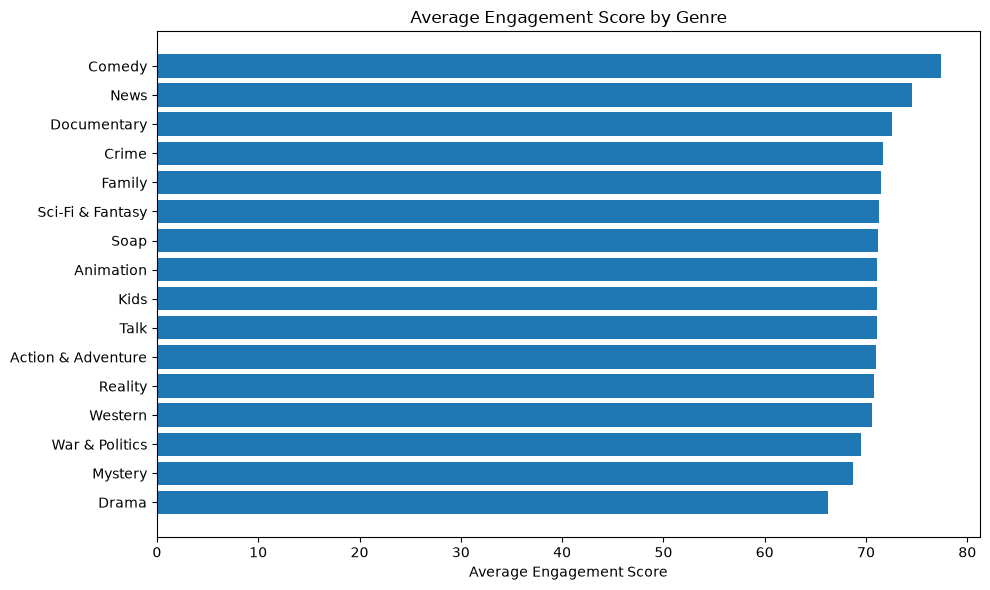

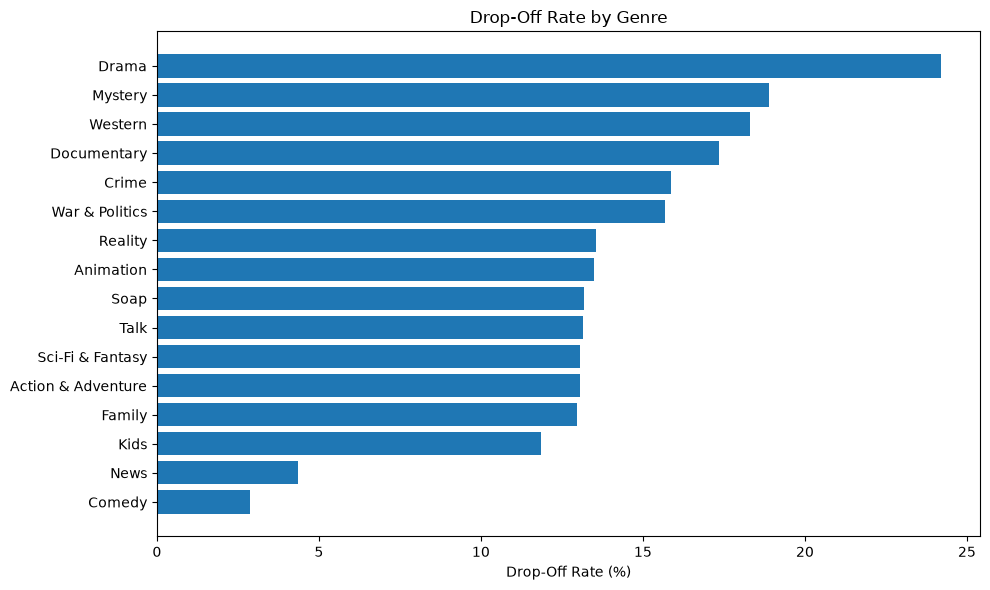

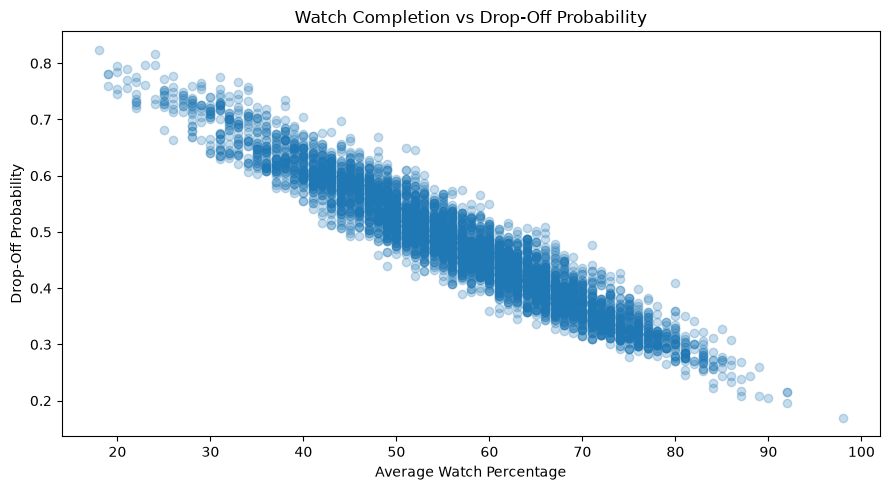

In [24]:
# PROCESS: Create a compact management-style dashboard from the final EDA metrics.
# Each chart is intentionally simple so the dashboard can be explained easily in an interview.

# KPI values
avg_watch = df["avg_watch_percentage"].mean()
high_risk_pct = (df["retention_risk"].astype(str).str.lower() == "high").mean() * 100
overall_drop_rate = df["drop_off"].mean() * 100
avg_engagement = df["engagement_score"].mean()

print("PORTFOLIO KPI SUMMARY")
print(f"Average watch percentage: {avg_watch:.2f}%")
print(f"Average engagement score: {avg_engagement:.2f}")
print(f"Overall drop-off rate: {overall_drop_rate:.2f}%")
print(f"High retention-risk share: {high_risk_pct:.2f}%")

# Chart 1: engagement by genre
genre_eng = df.groupby("genre")["engagement_score"].mean().sort_values()
plt.figure(figsize=(10, 6))
plt.barh(genre_eng.index, genre_eng.values)
plt.title("Average Engagement Score by Genre")
plt.xlabel("Average Engagement Score")
plt.tight_layout()
plt.show()
plt.close()

# Chart 2: drop-off rate by genre
genre_drop = (df.groupby("genre")["drop_off"].mean() * 100).sort_values()
plt.figure(figsize=(10, 6))
plt.barh(genre_drop.index, genre_drop.values)
plt.title("Drop-Off Rate by Genre")
plt.xlabel("Drop-Off Rate (%)")
plt.tight_layout()
plt.show()
plt.close()

# Chart 3: watch completion vs drop-off probability
sample_df = df.sample(min(5000, len(df)), random_state=42)
plt.figure(figsize=(9, 5))
plt.scatter(sample_df["avg_watch_percentage"], sample_df["drop_off_probability"], alpha=0.25)
plt.title("Watch Completion vs Drop-Off Probability")
plt.xlabel("Average Watch Percentage")
plt.ylabel("Drop-Off Probability")
plt.tight_layout()
plt.show()
plt.close()

## Final Business Recommendations

1. **Prioritize promotion candidates with multiple positive signals.** Favor episodes/shows that rank highly on engagement and watch completion while remaining low on drop-off probability. Avoid promoting content solely because its engagement score is high.
2. **Investigate low-completion/high-drop-off episodes first.** The strong inverse association between watch percentage and drop-off probability makes this combination the clearest operational warning signal in the dataset.
3. **Strengthen openings and pacing.** Hook strength and pacing both show meaningful positive relationships with engagement/completion, so weak openings or slow pacing should be reviewed for poorly performing episodes.
4. **Review cognitively demanding high-risk content.** High-risk episodes show higher cognitive load and lower completion. Content teams could examine whether exposition, dialogue complexity, or narrative density creates unnecessary friction.
5. **Use pause behavior as a secondary diagnostic.** High-risk episodes have more pauses on average, which may indicate distraction, complexity, or lower viewing flow. Rewinds appear much less informative for watch completion in this dataset.
6. **Do not use runtime as a primary optimization target.** Episode duration has almost no linear relationship with watch percentage here, so shortening content alone is not supported by this EDA.

## Project Limitations

- The viewer-behaviour fields are **synthetically generated**; results are not proprietary Hotstar analytics.
- The engagement score is a **constructed project metric**, not a validated industry KPI.
- Correlation and group differences identify association, **not causation**.
- The data is episode-level and may contain multiple records related to the same title; conclusions must distinguish records from unique shows.
- Season-level conclusions are limited because the supplied data represents Season 1 in the observed season field.
- EDA does not control for all possible confounders such as audience segment, device, geography, marketing exposure, or release timing.
- The project intentionally does not use machine learning or advanced statistical modeling because those methods are excluded by the brief.

## What I Learned From This Project

Through this project, I practiced an end-to-end EDA workflow: loading and validating episode-level data, checking missing values and duplicates, distinguishing categorical and numerical variables, creating a business-facing engagement metric, building visual comparisons, analyzing drop-off and retention risk, interpreting correlations carefully, and converting analytical outputs into content recommendations.

The most important lesson was that **a useful business recommendation should combine multiple signals rather than rely on one metric**. High engagement is more convincing when it is supported by strong watch completion and low drop-off probability, while high-risk content becomes more actionable when low completion, high cognitive load, pauses, and drop-off signals align.

## Local Project Path

For your Windows project folder, use:

`D:\project\_2\_Ott\_Viewer\_Engagement\_Analysis`

Recommended contents of that folder:

- all 14 `.ipynb` notebooks
- `ott_viewer_dropoff_retention_us_v1.0.csv`
- `README.md`
- `PROJECT_PATH.txt`

## Engagement Metric — Interpretation and Normalization

The project brief provides a composite `engagement_score` formula as an example.  
For assignment compatibility, the original formula is retained. However, it should be interpreted as an **engagement index**, not a percentage or probability, because its theoretical range can exceed 100.

A second `normalized_engagement_score` is added on a 0–100 style scale for easier communication. This normalized score is still a custom exploratory metric, not a scientifically validated measurement.

In [25]:
# Assignment-defined composite index.
df["engagement_index"] = (
    df["avg_watch_percentage"]
    + df["hook_strength"] * 5
    + df["pacing_score"] * 5
    + df["visual_intensity"] * 5
) / 2

# Keep the original column name for compatibility with the assignment brief.
df["engagement_score"] = df["engagement_index"]

# Optional 0–100 style normalized composite for easier business communication.
# Each 1–10 content score is converted approximately to a 0–100 scale first.
df["normalized_engagement_score"] = (
    df["avg_watch_percentage"] * 0.40
    + (df["hook_strength"] * 10) * 0.20
    + (df["pacing_score"] * 10) * 0.20
    + (df["visual_intensity"] * 10) * 0.20
)

display(
    df[["engagement_index", "normalized_engagement_score"]]
    .describe()
    .round(2)
)

,engagement_index,normalized_engagement_score
count,33171.00,33171.00
mean,70.73,56.59
std,12.02,9.62
min,30.00,24.00
25%,62.50,50.00
50%,71.00,56.80
75%,79.50,63.60
max,117.50,94.00


## Content Segmentation

A simple four-quadrant business segmentation combines engagement and drop-off risk without using machine learning.  
Median cut-offs are used only as transparent exploratory thresholds.

In [26]:
engagement_cut = df["engagement_index"].median()
drop_cut = df["drop_off_probability"].median()

df["content_segment"] = np.select(
    [
        (df["engagement_index"] >= engagement_cut) &
        (df["drop_off_probability"] < drop_cut),

        (df["engagement_index"] >= engagement_cut) &
        (df["drop_off_probability"] >= drop_cut),

        (df["engagement_index"] < engagement_cut) &
        (df["drop_off_probability"] < drop_cut)
    ],
    [
        "High Engagement / Low Risk",
        "High Engagement / High Risk",
        "Low Engagement / Low Risk"
    ],
    default="Low Engagement / High Risk"
)

segment_summary = (
    df["content_segment"]
    .value_counts()
    .to_frame("episodes")
)

segment_summary["percentage"] = (
    segment_summary["episodes"] / len(df) * 100
)

display(segment_summary.round(2))

,episodes,percentage
content_segment,,
Low Engagement / High Risk,13460,40.58
High Engagement / Low Risk,13417,40.45
High Engagement / High Risk,3240,9.77
Low Engagement / Low Risk,3054,9.21


## Explicit Promotion and Investigation Rules

Rather than selecting content only because it ranks highly on one metric, the rules below combine several business-relevant signals.

**Promotion candidates**
- Top 25% engagement index
- Top 25% watch completion
- Bottom 25% drop-off probability
- Not classified as high retention risk

**Investigation candidates**
- Bottom 25% watch completion
- Top 25% drop-off probability
- High retention risk

In [27]:
high_eng_cut = df["engagement_index"].quantile(0.75)
high_watch_cut = df["avg_watch_percentage"].quantile(0.75)
low_drop_cut = df["drop_off_probability"].quantile(0.25)

low_watch_cut = df["avg_watch_percentage"].quantile(0.25)
high_drop_cut = df["drop_off_probability"].quantile(0.75)

is_high_risk = (
    df["retention_risk"]
    .astype(str)
    .str.lower()
    .eq("high")
)

promotion_candidates = df[
    (df["engagement_index"] >= high_eng_cut) &
    (df["avg_watch_percentage"] >= high_watch_cut) &
    (df["drop_off_probability"] <= low_drop_cut) &
    (~is_high_risk)
].copy()

investigation_candidates = df[
    (df["avg_watch_percentage"] <= low_watch_cut) &
    (df["drop_off_probability"] >= high_drop_cut) &
    (is_high_risk)
].copy()

promotion_columns = [
    "title", "season_number", "episode_number", "genre",
    "engagement_index", "avg_watch_percentage",
    "drop_off_probability", "retention_risk"
]

investigation_columns = [
    "title", "season_number", "episode_number", "genre",
    "avg_watch_percentage", "drop_off_probability",
    "hook_strength", "pacing_score", "cognitive_load",
    "retention_risk"
]

print("Promotion candidates:", len(promotion_candidates))
display(
    promotion_candidates[promotion_columns]
    .sort_values(
        ["engagement_index", "avg_watch_percentage"],
        ascending=False
    )
    .head(20)
    .round(2)
)

print("\nInvestigation candidates:", len(investigation_candidates))
display(
    investigation_candidates[investigation_columns]
    .sort_values(
        ["drop_off_probability", "avg_watch_percentage"],
        ascending=[False, True]
    )
    .head(20)
    .round(2)
)

Promotion candidates: 5437


,title,season_number,episode_number,genre,engagement_index,avg_watch_percentage,drop_off_probability,retention_risk
16149,30 Rock,1,1,Comedy,117.5,100,0.12,low
1840,Young Sheldon,1,1,Comedy,114.5,99,0.15,low
13312,Buffy the Vampire Slayer,1,1,Sci-Fi & Fantasy,111.5,98,0.17,low
7315,The Late Show with Stephen Colbert,1,12,Comedy,109.5,94,0.19,low
1408,Tagesschau,1,1,News,108.0,86,0.24,low
1198,Arrow,1,1,Crime,107.5,85,0.24,low
27533,Good Mythical Morning,1,50,Comedy,107.0,89,0.22,low
33099,The Cosby Show,1,6,Comedy,107.0,89,0.21,low
197,Law & Order,1,1,Crime,106.5,98,0.22,low
2342,Running Man,1,244,Comedy,106.5,88,0.24,low



Investigation candidates: 4700


,title,season_number,episode_number,genre,avg_watch_percentage,drop_off_probability,hook_strength,pacing_score,cognitive_load,retention_risk
20822,Blood Flowers,1,42,Drama,21,0.83,3,4,9,high
6280,Doraemon,1,1259,Action & Adventure,18,0.82,3,4,9,high
21860,Pleasant Goat and Big Big Wolf,1,510,Animation,23,0.82,3,4,9,high
15252,A Kindred Spirit,1,1113,Drama,21,0.82,3,4,9,high
31170,Show! Music Core,1,762,Reality,24,0.82,3,4,9,high
14403,A Kindred Spirit,1,264,Drama,20,0.82,3,3,9,high
31394,Station 19,1,5,Drama,16,0.81,3,3,9,high
25255,This Is Us,1,6,Drama,23,0.81,3,4,9,high
32169,CID,1,623,Action & Adventure,19,0.81,3,4,9,high
10680,Sazae-san,1,2160,Animation,15,0.81,3,4,9,high


## Analytical Language Standard

Use association language throughout the project:

- Prefer **“Higher hook strength is associated with higher/lower watch percentage.”**
- Avoid **“Hook strength causes watch percentage to increase.”**
- Prefer **“High-risk episodes show different cognitive-load patterns.”**
- Avoid **“Cognitive load causes retention risk.”**

This project is observational EDA on synthetic data; causal conclusions are not supported.

## Final Portfolio Standard

This project intentionally remains **EDA-only**.

**Used**
- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn

**Not used**
- Scikit-learn
- Plotly
- Power BI
- Tableau
- Machine Learning
- Statistical libraries beyond NumPy/Pandas

## Refinement for Business Questions 5 and 6

The composite engagement index contains hook strength and pacing by definition.  
To avoid circular reasoning, the primary evidence for these questions is their relationship with **observed average watch percentage**.

This keeps the conclusion tied to viewer behavior rather than to a formula that already includes the predictor.

In [28]:
hook_vs_watch = df["hook_strength"].corr(df["avg_watch_percentage"])
pacing_vs_watch = df["pacing_score"].corr(df["avg_watch_percentage"])

refined_q5_q6 = pd.DataFrame({
    "business_question": [
        "Does hook strength relate to viewer completion?",
        "Does pacing relate to viewer completion?"
    ],
    "primary_metric": [
        "hook_strength vs avg_watch_percentage",
        "pacing_score vs avg_watch_percentage"
    ],
    "correlation": [
        hook_vs_watch,
        pacing_vs_watch
    ]
})

display(refined_q5_q6.round(4))

print(
    "Use these observed-watch relationships as the primary interpretation. "
    "Do not infer causation."
)

,business_question,primary_metric,correlation
0,Does hook strength relate to viewer completion?,hook_strength vs avg_watch_percentage,0.5524
1,Does pacing relate to viewer completion?,pacing_score vs avg_watch_percentage,0.5936


Use these observed-watch relationships as the primary interpretation. Do not infer causation.


## Repeated Episode Observation Note

The dataset contains non-unique combinations of `show_id + season_number + episode_number`, but the corresponding rows are not exact duplicates because behavioral fields differ.

Therefore, these rows are treated as **repeated episode observations** rather than automatically deleted.  
This limitation should be disclosed when presenting episode-level rankings or aggregations.

In [29]:
# KERNEL-SAFE CLEANUP
plt.close('all')
gc.collect()
print('Notebook cleanup complete.')

Notebook cleanup complete.
